In [1]:
!pip install timm tqdm kaggle

import torch
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader
from torchvision.datasets import ImageFolder
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import timm
from tqdm import tqdm
import os
import shutil

In [2]:
#2
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


In [3]:
#3
import urllib.request
import zipfile

url = "http://cs231n.stanford.edu/tiny-imagenet-200.zip"
filename = "tiny-imagenet-200.zip"

print("Downloading dataset...")
urllib.request.urlretrieve(url, filename)

print("Unzipping...")
with zipfile.ZipFile(filename, 'r') as zip_ref:
    zip_ref.extractall()

print("Done!")

Unzipping...
Done!


In [4]:
#4
import os
import shutil

val_dir = '/content/tiny-imagenet-200/val'
img_dir = os.path.join(val_dir, 'images')
annot_file = os.path.join(val_dir, 'val_annotations.txt')

# Move images to class folders
with open(annot_file) as f:
    for line in f:
        img, label = line.split('\t')[:2]

        label_dir = os.path.join(val_dir, label)
        os.makedirs(label_dir, exist_ok=True)

        src = os.path.join(img_dir, img)
        dst = os.path.join(label_dir, img)

        if os.path.exists(src):
            shutil.move(src, dst)

# 🔥 REMOVE the 'images' folder completely
if os.path.exists(img_dir):
    shutil.rmtree(img_dir)

print("Validation fully fixed ✅")

Validation fully fixed ✅


In [5]:
#5
from torchvision.datasets import ImageFolder

train_dir = '/content/tiny-imagenet-200/train'
val_dir = '/content/tiny-imagenet-200/val'

# NO transform here ❗
train_dataset = ImageFolder(train_dir)
val_dataset = ImageFolder(val_dir)

print("Train:", len(train_dataset))
print("Val:", len(val_dataset))

Train: 100000
Val: 10000


In [6]:
import torchvision.transforms as transforms

def get_transforms():
    return [
        transforms.Compose([
            transforms.Resize((64, 64)),
            transforms.ToTensor()
        ]),
        transforms.Compose([
            transforms.Resize((32, 32)),
            transforms.ToTensor()
        ])
    ]

In [7]:
#7
from torch.utils.data import Dataset

class MultiResDataset(Dataset):
    def __init__(self, dataset, transforms_list):
        self.dataset = dataset
        self.transforms_list = transforms_list

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        img, label = self.dataset[idx]

        # Apply multiple transforms
        imgs = [t(img) for t in self.transforms_list]

        return imgs, label

In [8]:
#8
transforms_list = get_transforms()

train_data = MultiResDataset(train_dataset, transforms_list)
val_data = MultiResDataset(val_dataset, transforms_list)

train_loader = DataLoader(train_data, batch_size=32, shuffle=True)

In [9]:
import timm

model = timm.create_model('resnet18', pretrained=False, num_classes=200)
model = model.to(device)

print("Model ready")

Model ready


In [10]:
#10
import torch.nn as nn
import torch.optim as optim

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

print("Loss & optimizer ready")

Loss & optimizer ready


In [11]:
#11
import torch.nn.functional as F

def consistency_loss(outputs):
    loss = 0
    count = 0

    for i in range(len(outputs)):
        for j in range(i+1, len(outputs)):
            loss += F.kl_div(
                F.log_softmax(outputs[i], dim=1),
                F.softmax(outputs[j], dim=1),
                reduction='batchmean'
            )
            count += 1

    return loss / count

In [12]:
#12
def train(model, loader):
    model.train()
    total_loss = 0

    for imgs, labels in tqdm(loader):
        labels = labels.to(device)

        outputs = []
        for img in imgs:
            img = img.to(device)
            outputs.append(model(img))

        ce = criterion(outputs[0], labels)
        cons = consistency_loss(outputs)

        loss = ce + 0.5 * cons

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(loader)

In [13]:
#13
for epoch in range(3):
    print(f"Epoch {epoch+1}")
    loss = train(model, train_loader)
    print("Loss:", loss)

Epoch 1


100%|██████████| 3125/3125 [02:48<00:00, 18.52it/s]


Loss: 4.297638804855347
Epoch 2


100%|██████████| 3125/3125 [02:44<00:00, 19.00it/s]


Loss: 3.54141822555542
Epoch 3


100%|██████████| 3125/3125 [02:44<00:00, 19.00it/s]

Loss: 3.1781683343505858


In [14]:
torch.save(model.state_dict(), "model.pth")
print("Model saved locally ✅")

Model saved locally ✅


In [15]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [16]:
torch.save(model.state_dict(), "/content/drive/MyDrive/model.pth")
print("Saved to Drive ✅")

Saved to Drive ✅


In [17]:
#Evaluate Accuracy
def evaluate(model, loader):
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for imgs, labels in loader:
            labels = labels.to(device)

            # use highest resolution (64x64)
            outputs = model(imgs[0].to(device))

            _, predicted = torch.max(outputs, 1)

            correct += (predicted == labels).sum().item()
            total += labels.size(0)

    return 100 * correct / total

In [18]:
acc = evaluate(model, train_loader)
print("Train Accuracy:", acc)

Train Accuracy: 27.364


In [20]:
val_loader = DataLoader(val_data, batch_size=32, shuffle=False)
print("Validation loader ready ✅")

Validation loader ready ✅


In [21]:
val_acc = evaluate(model, val_loader)
print("Validation Accuracy:", val_acc)

Validation Accuracy: 21.3


In [22]:
def test_low_res(model, loader):
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for imgs, labels in loader:
            labels = labels.to(device)

            # LOW resolution (32x32)
            outputs = model(imgs[1].to(device))

            _, predicted = torch.max(outputs, 1)

            correct += (predicted == labels).sum().item()
            total += labels.size(0)

    return 100 * correct / total

In [23]:
low_acc = test_low_res(model, val_loader)
print("Low Resolution Accuracy:", low_acc)

Low Resolution Accuracy: 13.06


In [24]:
loss_history = []

epochs = 3

for epoch in range(epochs):
    print(f"Epoch {epoch+1}")
    loss = train(model, train_loader)
    print("Loss:", loss)

    loss_history.append(loss)

Epoch 1


100%|██████████| 3125/3125 [02:52<00:00, 18.13it/s]


Loss: 2.8697768376922608
Epoch 2


100%|██████████| 3125/3125 [02:47<00:00, 18.68it/s]


Loss: 2.57626074508667
Epoch 3


100%|██████████| 3125/3125 [02:47<00:00, 18.61it/s]

Loss: 2.2784337717437744


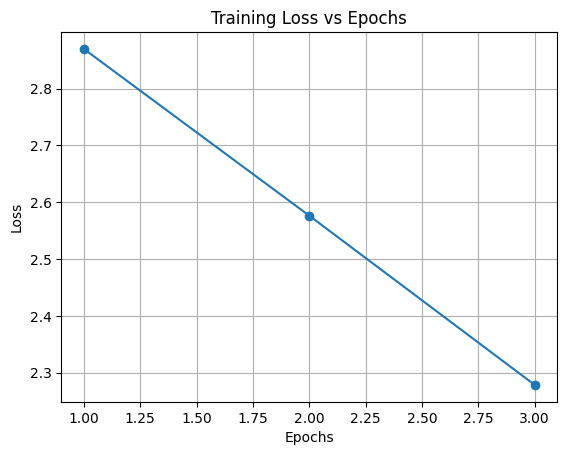

In [25]:
import matplotlib.pyplot as plt

plt.plot(range(1, len(loss_history)+1), loss_history, marker='o')
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training Loss vs Epochs")
plt.grid()

plt.show()
#“The loss decreases with epochs, showing that the model is learning.”

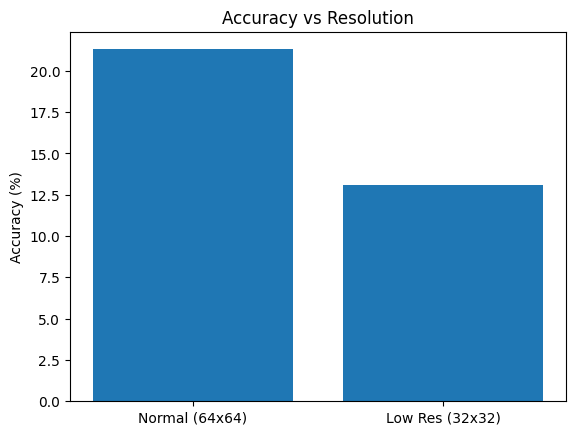

In [26]:
labels = ['Normal (64x64)', 'Low Res (32x32)']
values = [val_acc, low_acc]

plt.bar(labels, values)
plt.ylabel("Accuracy (%)")
plt.title("Accuracy vs Resolution")

plt.show()
#“We can see a drop in accuracy when resolution decreases, which shows the challenge of maintaining consistency.”